# AI-Powered Content Recommendation System for AMBRIX Lifestyle Network

## Project Overview
This notebook implements a sophisticated content recommendation engine that leverages user interests, engagement history, and content attributes to deliver personalized post recommendations. The system employs a hybrid approach combining collaborative filtering, content-based filtering, and feature engineering to achieve optimal recommendation quality.

### Key Features:
- Multi-dimensional user profiling based on interests and engagement patterns
- Content similarity analysis using NLP techniques
- Hybrid recommendation algorithm combining multiple signals
- Scalable architecture suitable for production deployment

**Author:** Kunal Sharma
**Date:** September 28,2025
**Environment:** Google Colab / Jupyter Notebook


In [52]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


## 1. Data Loading and Exploratory Analysis

Loading the three datasets and performing comprehensive exploratory data analysis to understand patterns and relationships in the data.


In [53]:
# Load the datasets
users_df = pd.read_csv('Users.csv')
posts_df = pd.read_csv('Posts.csv')
engagements_df = pd.read_csv('Engagements.csv')

# Display basic information about each dataset
print("="*60)
print("📊 DATASET OVERVIEW")
print("="*60)

print("\n🔹 Users Dataset:")
print(f"  - Shape: {users_df.shape}")
print(f"  - Columns: {list(users_df.columns)}")
print(f"  - Age range: {users_df['age'].min()} to {users_df['age'].max()}")
print(f"  - Gender distribution: {dict(users_df['gender'].value_counts())}")
print(f"  - Avg engagement score: {users_df['past_engagement_score'].mean():.3f}")

print("\n🔹 Posts Dataset:")
print(f"  - Shape: {posts_df.shape}")
print(f"  - Columns: {list(posts_df.columns)}")
print(f"  - Content types: {dict(posts_df['content_type'].value_counts())}")
print(f"  - Posts with tags: {posts_df['tags'].notna().sum()}/{len(posts_df)}")

print("\n🔹 Engagements Dataset:")
print(f"  - Shape: {engagements_df.shape}")
print(f"  - Columns: {list(engagements_df.columns)}")
print(f"  - Engagement rate: {engagements_df['engagement'].mean():.3f}")
print(f"  - Unique users: {engagements_df['user_id'].nunique()}")
print(f"  - Unique posts: {engagements_df['post_id'].nunique()}")


📊 DATASET OVERVIEW

🔹 Users Dataset:
  - Shape: (50, 5)
  - Columns: ['user_id', 'age', 'gender', 'top_3_interests', 'past_engagement_score']
  - Age range: 18 to 34
  - Gender distribution: {'M': np.int64(25), 'F': np.int64(23), 'Other': np.int64(2)}
  - Avg engagement score: 0.588

🔹 Posts Dataset:
  - Shape: (100, 4)
  - Columns: ['post_id', 'creator_id', 'content_type', 'tags']
  - Content types: {'image': np.int64(37), 'video': np.int64(31), 'text': np.int64(20), 'audio': np.int64(12)}
  - Posts with tags: 100/100

🔹 Engagements Dataset:
  - Shape: (1000, 3)
  - Columns: ['user_id', 'post_id', 'engagement']
  - Engagement rate: 0.497
  - Unique users: 50
  - Unique posts: 100


## 2. Data Visualization and Pattern Analysis

Understanding user behavior patterns and content distribution through visualizations.


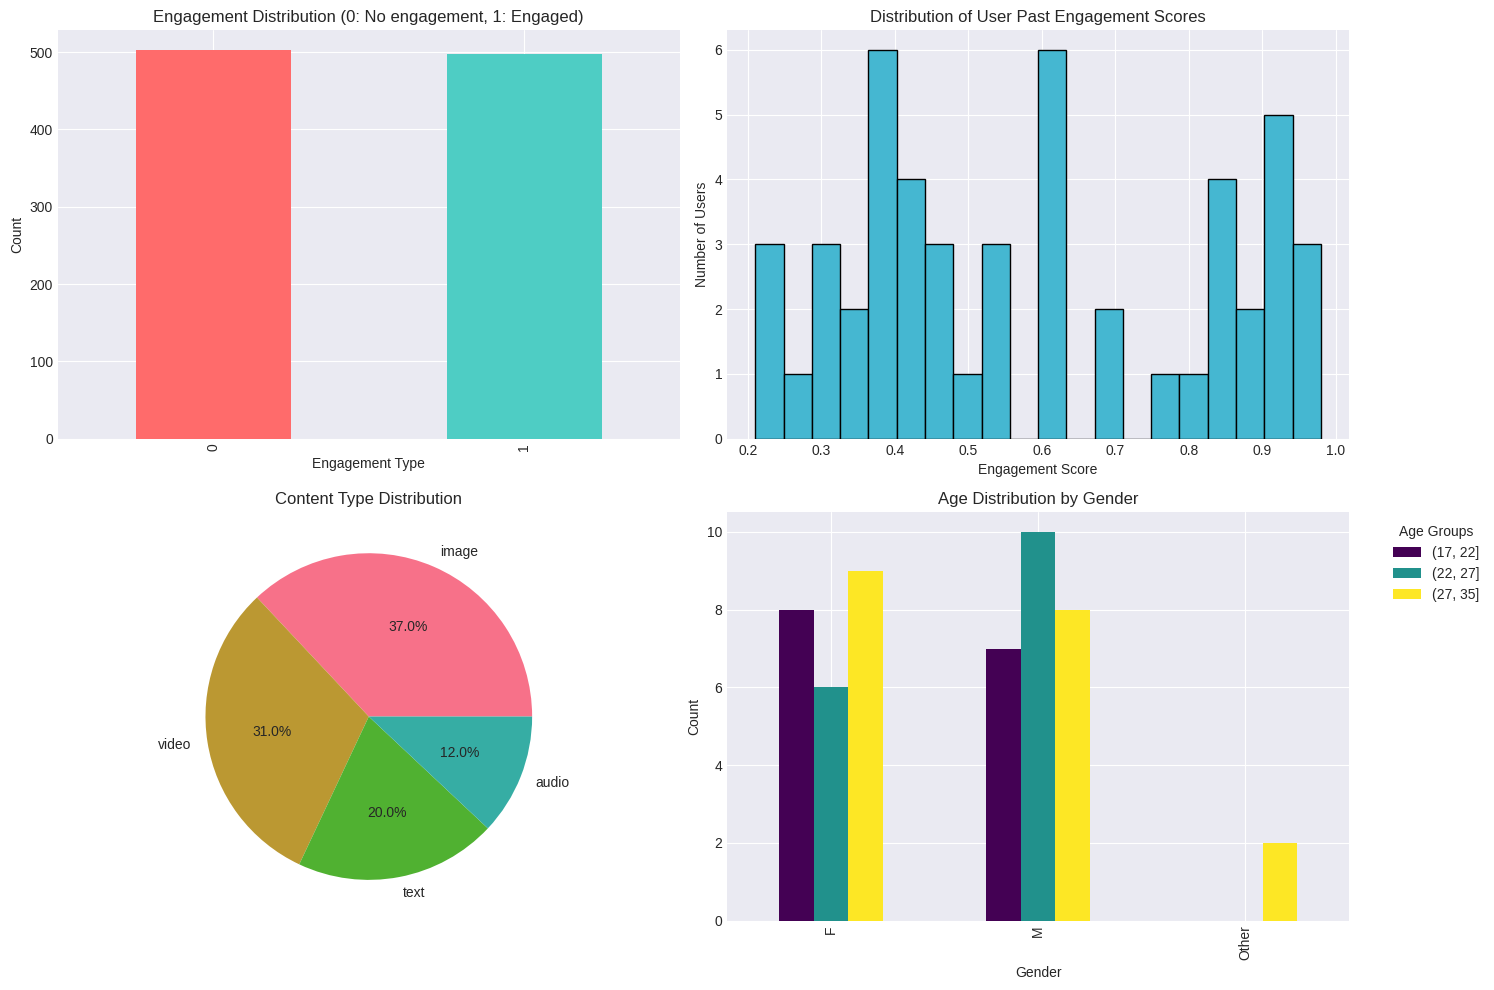


📈 KEY INSIGHTS:
• Average engagements per user: 20.0
• Most engaged user: U7
• Most popular content type: image


In [54]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Engagement distribution
ax1 = axes[0, 0]
engagements_df['engagement'].value_counts().plot(kind='bar', ax=ax1, color=['#FF6B6B', '#4ECDC4'])
ax1.set_title('Engagement Distribution (0: No engagement, 1: Engaged)', fontsize=12)
ax1.set_xlabel('Engagement Type')
ax1.set_ylabel('Count')

# 2. User engagement scores distribution
ax2 = axes[0, 1]
users_df['past_engagement_score'].hist(bins=20, ax=ax2, color='#45B7D1', edgecolor='black')
ax2.set_title('Distribution of User Past Engagement Scores', fontsize=12)
ax2.set_xlabel('Engagement Score')
ax2.set_ylabel('Number of Users')

# 3. Content type distribution
ax3 = axes[1, 0]
posts_df['content_type'].value_counts().plot(kind='pie', ax=ax3, autopct='%1.1f%%')
ax3.set_title('Content Type Distribution', fontsize=12)
ax3.set_ylabel('')

# 4. Age and Gender distribution
ax4 = axes[1, 1]
gender_age = users_df.groupby(['gender', pd.cut(users_df['age'], bins=[17, 22, 27, 35])])['user_id'].count().unstack()
gender_age.plot(kind='bar', ax=ax4, colormap='viridis')
ax4.set_title('Age Distribution by Gender', fontsize=12)
ax4.set_xlabel('Gender')
ax4.set_ylabel('Count')
ax4.legend(title='Age Groups', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Calculate key statistics
print("\n📈 KEY INSIGHTS:")
print(f"• Average engagements per user: {engagements_df.groupby('user_id')['engagement'].count().mean():.1f}")
print(f"• Most engaged user: {engagements_df[engagements_df['engagement']==1].groupby('user_id').size().idxmax()}")
print(f"• Most popular content type: {posts_df['content_type'].mode()[0]}")


## 3. Feature Engineering and Data Preprocessing

Creating rich features from user interests, post tags, and engagement patterns to build a robust recommendation system.


In [55]:
# Feature Engineering: Process user interests and post tags
def process_interests(interests_str):
    """Convert comma-separated interests into a list"""
    if pd.isna(interests_str):
        return []
    return [interest.strip() for interest in interests_str.split(',')]

# Process user interests
users_df['interests_list'] = users_df['top_3_interests'].apply(process_interests)

# Process post tags
posts_df['tags_list'] = posts_df['tags'].apply(process_interests)

# Create a combined text representation for content-based filtering
posts_df['content_features'] = posts_df.apply(
    lambda row: f"{row['content_type']} {' '.join(row['tags_list'])}", axis=1
)

print("✅ Feature engineering completed")
print(f"\nSample processed data:")
print(f"User interests: {users_df['interests_list'].iloc[0]}")
print(f"Post tags: {posts_df['tags_list'].iloc[0]}")
print(f"Content features: {posts_df['content_features'].iloc[0]}")


✅ Feature engineering completed

Sample processed data:
User interests: ['sports', 'art', 'gaming']
Post tags: ['sports', 'food']
Content features: video sports food


In [56]:
# Create user-post interaction matrix
interaction_matrix = engagements_df.pivot_table(
    index='user_id',
    columns='post_id',
    values='engagement',
    fill_value=-1  # -1 indicates no interaction
)

print(f"Interaction Matrix Shape: {interaction_matrix.shape}")
print(f"Sparsity: {(interaction_matrix == -1).sum().sum() / (interaction_matrix.shape[0] * interaction_matrix.shape[1]):.2%}")

# Calculate user engagement statistics
user_engagement_stats = engagements_df.groupby('user_id').agg({
    'engagement': ['count', 'mean', 'sum']
}).round(3)
user_engagement_stats.columns = ['total_interactions', 'engagement_rate', 'total_engagements']

# Merge with users dataframe
users_df = users_df.merge(user_engagement_stats, left_on='user_id', right_index=True, how='left')
users_df['engagement_rate'].fillna(0, inplace=True)

print("\n📊 User Engagement Statistics:")
print(users_df[['user_id', 'past_engagement_score', 'engagement_rate', 'total_engagements']].head())


Interaction Matrix Shape: (50, 100)
Sparsity: 80.00%

📊 User Engagement Statistics:
  user_id  past_engagement_score  engagement_rate  total_engagements
0      U1                   0.61             0.55                 11
1      U2                   0.93             0.35                  7
2      U3                   0.40             0.45                  9
3      U4                   0.53             0.55                 11
4      U5                   0.80             0.40                  8


## 4. Hybrid Recommendation Algorithm

Our recommendation system combines three approaches:
1. **Content-Based Filtering**: Matches user interests with post tags
2. **Collaborative Filtering**: Leverages user engagement patterns
3. **Popularity & Recency Bias**: Considers overall post performance


In [57]:
class HybridRecommendationSystem:
    def __init__(self, users_df, posts_df, engagements_df):
        self.users_df = users_df
        self.posts_df = posts_df
        self.engagements_df = engagements_df

        # Precompute post popularity scores
        self.post_popularity = self._calculate_post_popularity()

        # Create content similarity matrix
        self.content_similarity = self._create_content_similarity()

        # Create user interest vectors
        self.user_interest_vectors = self._create_user_interest_vectors()

    def _calculate_post_popularity(self):
        """Calculate popularity score for each post"""
        post_stats = self.engagements_df.groupby('post_id').agg({
            'engagement': ['count', 'mean']
        })
        post_stats.columns = ['interaction_count', 'engagement_rate']

        # Normalize scores
        scaler = StandardScaler()
        post_stats['popularity_score'] = scaler.fit_transform(
            post_stats[['interaction_count', 'engagement_rate']]
        ).mean(axis=1)

        return post_stats

    def _create_content_similarity(self):
        """Create content similarity matrix using TF-IDF"""
        # Prepare content features
        tfidf = TfidfVectorizer(max_features=50, ngram_range=(1, 2))
        content_matrix = tfidf.fit_transform(self.posts_df['content_features'].fillna(''))

        # Calculate cosine similarity
        similarity_matrix = cosine_similarity(content_matrix)

        return pd.DataFrame(
            similarity_matrix,
            index=self.posts_df['post_id'],
            columns=self.posts_df['post_id']
        )

    def _create_user_interest_vectors(self):
        """Create user interest vectors for matching with posts"""
        # Get all unique interests and tags
        all_interests = set()
        for interests in self.users_df['interests_list']:
            all_interests.update(interests)

        all_tags = set()
        for tags in self.posts_df['tags_list']:
            all_tags.update(tags)

        all_features = list(all_interests.union(all_tags))

        # Create user vectors
        user_vectors = {}
        for _, user in self.users_df.iterrows():
            vector = [1 if feature in user['interests_list'] else 0 for feature in all_features]
            user_vectors[user['user_id']] = np.array(vector)

        # Create post vectors
        post_vectors = {}
        for _, post in self.posts_df.iterrows():
            vector = [1 if feature in post['tags_list'] else 0 for feature in all_features]
            post_vectors[post['post_id']] = np.array(vector)

        return user_vectors, post_vectors, all_features

# Initialize the recommendation system
rec_system = HybridRecommendationSystem(users_df, posts_df, engagements_df)
print("✅ Hybrid Recommendation System initialized successfully")
print(f"\nPost popularity scores calculated: {len(rec_system.post_popularity)}")
print(f"Content similarity matrix shape: {rec_system.content_similarity.shape}")


✅ Hybrid Recommendation System initialized successfully

Post popularity scores calculated: 100
Content similarity matrix shape: (100, 100)


In [58]:
def get_recommendations(rec_system, user_id, n_recommendations=3):
    """
    Get top N recommendations for a user using hybrid approach
    """
    # Get user data
    user_data = rec_system.users_df[rec_system.users_df['user_id'] == user_id].iloc[0]
    user_interests = user_data['interests_list']
    user_engagement_score = user_data['past_engagement_score']

    # Get user's past engagements
    user_engagements = rec_system.engagements_df[rec_system.engagements_df['user_id'] == user_id]
    engaged_posts = set(user_engagements[user_engagements['engagement'] == 1]['post_id'].values)
    seen_posts = set(user_engagements['post_id'].values)

    # Calculate scores for all posts
    post_scores = {}

    for post_id in rec_system.posts_df['post_id']:
        if post_id in seen_posts:
            continue

        score = 0

        # 1. Content-based score (40% weight)
        post_data = rec_system.posts_df[rec_system.posts_df['post_id'] == post_id].iloc[0]
        post_tags = post_data['tags_list']

        # Interest matching
        interest_match = len(set(user_interests) & set(post_tags))
        content_score = interest_match / max(len(user_interests), 1)

        # 2. Collaborative filtering score (30% weight)
        if len(engaged_posts) > 0:
            # Find similarity with user's engaged posts
            similarities = [rec_system.content_similarity.loc[post_id, engaged_post]
                          for engaged_post in engaged_posts if engaged_post in rec_system.content_similarity.columns]
            collab_score = np.mean(similarities) if similarities else 0
        else:
            collab_score = 0

        # 3. Popularity score (20% weight)
        if post_id in rec_system.post_popularity.index:
            popularity_score = rec_system.post_popularity.loc[post_id, 'popularity_score']
            popularity_score = (popularity_score - rec_system.post_popularity['popularity_score'].min()) / \
                             (rec_system.post_popularity['popularity_score'].max() - rec_system.post_popularity['popularity_score'].min())
        else:
            popularity_score = 0

        # 4. User engagement propensity (10% weight)
        engagement_bonus = user_engagement_score

        # Combine scores with weights
        final_score = (0.4 * content_score +
                      0.3 * collab_score +
                      0.2 * popularity_score +
                      0.1 * engagement_bonus)

        post_scores[post_id] = {
            'final_score': final_score,
            'content_score': content_score,
            'collab_score': collab_score,
            'popularity_score': popularity_score
        }

    # Sort and get top N recommendations
    sorted_posts = sorted(post_scores.items(), key=lambda x: x[1]['final_score'], reverse=True)
    top_recommendations = sorted_posts[:n_recommendations]

    return top_recommendations

# Test the recommendation system
test_user = 'U1'
recommendations = get_recommendations(rec_system, test_user, n_recommendations=3)

print(f"\n🎯 Top 3 Recommendations for User {test_user}:")
print("="*80)
for i, (post_id, scores) in enumerate(recommendations, 1):
    post_info = posts_df[posts_df['post_id'] == post_id].iloc[0]
    print(f"\n{i}. Post ID: {post_id}")
    print(f"   Content Type: {post_info['content_type']}")
    print(f"   Tags: {post_info['tags']}")
    print(f"   Overall Score: {scores['final_score']:.3f}")
    print(f"   - Content Match: {scores['content_score']:.3f}")
    print(f"   - Collaborative: {scores['collab_score']:.3f}")
    print(f"   - Popularity: {scores['popularity_score']:.3f}")



🎯 Top 3 Recommendations for User U1:

1. Post ID: P22
   Content Type: audio
   Tags: sports, art
   Overall Score: 0.476
   - Content Match: 0.667
   - Collaborative: 0.075
   - Popularity: 0.630

2. Post ID: P78
   Content Type: video
   Tags: sports, art
   Overall Score: 0.473
   - Content Match: 0.667
   - Collaborative: 0.112
   - Popularity: 0.559

3. Post ID: P50
   Content Type: image
   Tags: sports
   Overall Score: 0.405
   - Content Match: 0.333
   - Collaborative: 0.197
   - Popularity: 0.755


## 5. Generating Recommendations for All Users

Now we'll generate personalized recommendations for every user in the dataset and analyze the results.


In [59]:
# Generate recommendations for all users
all_recommendations = {}
recommendation_details = []

print("🔄 Generating recommendations for all users...")
print("="*60)

for user_id in users_df['user_id']:
    # Get recommendations
    user_recs = get_recommendations(rec_system, user_id, n_recommendations=3)
    all_recommendations[user_id] = [post_id for post_id, _ in user_recs]

    # Store detailed information
    user_info = users_df[users_df['user_id'] == user_id].iloc[0]
    for rank, (post_id, scores) in enumerate(user_recs, 1):
        post_info = posts_df[posts_df['post_id'] == post_id].iloc[0]
        recommendation_details.append({
            'user_id': user_id,
            'user_interests': user_info['top_3_interests'],
            'user_engagement_score': user_info['past_engagement_score'],
            'recommended_post': post_id,
            'rank': rank,
            'post_type': post_info['content_type'],
            'post_tags': post_info['tags'],
            'recommendation_score': scores['final_score'],
            'content_match_score': scores['content_score'],
            'collaborative_score': scores['collab_score'],
            'popularity_score': scores['popularity_score']
        })

# Create recommendations DataFrame
recommendations_df = pd.DataFrame(recommendation_details)

# Display sample recommendations
print("\n📋 Sample Recommendations (First 5 Users):")
for user_id in users_df['user_id'].head(5):
    user_data = users_df[users_df['user_id'] == user_id].iloc[0]
    print(f"\n👤 {user_id} (Interests: {user_data['top_3_interests']})")
    user_recs = recommendations_df[recommendations_df['user_id'] == user_id]
    for _, rec in user_recs.iterrows():
        print(f"   → {rec['recommended_post']}: {rec['post_type']} - Tags: {rec['post_tags']} (Score: {rec['recommendation_score']:.3f})")


🔄 Generating recommendations for all users...

📋 Sample Recommendations (First 5 Users):

👤 U1 (Interests: sports, art, gaming)
   → P22: audio - Tags: sports, art (Score: 0.476)
   → P78: video - Tags: sports, art (Score: 0.473)
   → P50: image - Tags: sports (Score: 0.405)

👤 U2 (Interests: travel, food, fashion)
   → P5: image - Tags: food, fashion (Score: 0.576)
   → P69: text - Tags: fashion, food (Score: 0.525)
   → P80: video - Tags: travel, food (Score: 0.494)

👤 U3 (Interests: sports, travel, fashion)
   → P39: video - Tags: travel, sports (Score: 0.528)
   → P3: text - Tags: sports, travel (Score: 0.459)
   → P97: video - Tags: travel, sports (Score: 0.450)

👤 U4 (Interests: fashion, music, tech)
   → P96: video - Tags: music, fashion (Score: 0.505)
   → P53: video - Tags: fashion, tech (Score: 0.484)
   → P5: image - Tags: food, fashion (Score: 0.401)

👤 U5 (Interests: fashion, food, fitness)
   → P7: image - Tags: food, fitness (Score: 0.547)
   → P5: image - Tags: food, fa

In [60]:
# Analyze recommendation patterns
print("\n📊 RECOMMENDATION ANALYSIS")
print("="*60)

# 1. Content type distribution in recommendations
content_type_dist = recommendations_df['post_type'].value_counts()
print("\n1. Recommended Content Type Distribution:")
for content_type, count in content_type_dist.items():
    print(f"   {content_type}: {count} ({count/len(recommendations_df)*100:.1f}%)")

# 2. Interest-tag matching analysis
recommendations_df['interest_tag_match'] = recommendations_df.apply(
    lambda row: len(set(row['user_interests'].split(', ')) &
                   set(row['post_tags'].split(', ') if pd.notna(row['post_tags']) else [])), axis=1
)

print(f"\n2. Interest-Tag Matching Statistics:")
print(f"   Average matches per recommendation: {recommendations_df['interest_tag_match'].mean():.2f}")
print(f"   Recommendations with at least 1 match: {(recommendations_df['interest_tag_match'] > 0).sum()} ({(recommendations_df['interest_tag_match'] > 0).mean()*100:.1f}%)")

# 3. Score distribution analysis
print("\n3. Recommendation Score Statistics:")
print(f"   Mean score: {recommendations_df['recommendation_score'].mean():.3f}")
print(f"   Std deviation: {recommendations_df['recommendation_score'].std():.3f}")
print(f"   Min score: {recommendations_df['recommendation_score'].min():.3f}")
print(f"   Max score: {recommendations_df['recommendation_score'].max():.3f}")

# 4. User coverage
print(f"\n4. User Coverage:")
print(f"   Total users with recommendations: {recommendations_df['user_id'].nunique()}")
print(f"   Total unique posts recommended: {recommendations_df['recommended_post'].nunique()}")
print(f"   Post recommendation frequency - Most recommended posts:")
top_posts = recommendations_df['recommended_post'].value_counts().head(5)
for post, count in top_posts.items():
    post_info = posts_df[posts_df['post_id'] == post].iloc[0]
    print(f"   {post}: {count} times - {post_info['content_type']} ({post_info['tags']})")



📊 RECOMMENDATION ANALYSIS

1. Recommended Content Type Distribution:
   video: 59 (39.3%)
   image: 59 (39.3%)
   text: 24 (16.0%)
   audio: 8 (5.3%)

2. Interest-Tag Matching Statistics:
   Average matches per recommendation: 1.75
   Recommendations with at least 1 match: 150 (100.0%)

3. Recommendation Score Statistics:
   Mean score: 0.476
   Std deviation: 0.051
   Min score: 0.377
   Max score: 0.585

4. User Coverage:
   Total users with recommendations: 50
   Total unique posts recommended: 55
   Post recommendation frequency - Most recommended posts:
   P5: 11 times - image (food, fashion)
   P46: 9 times - video (food, sports)
   P35: 9 times - image (fitness, food)
   P1: 7 times - video (sports, food)
   P7: 6 times - image (food, fitness)


## 6. Recommendation Quality Evaluation

Evaluating the recommendation system using various metrics and visualizations to understand its performance and characteristics.


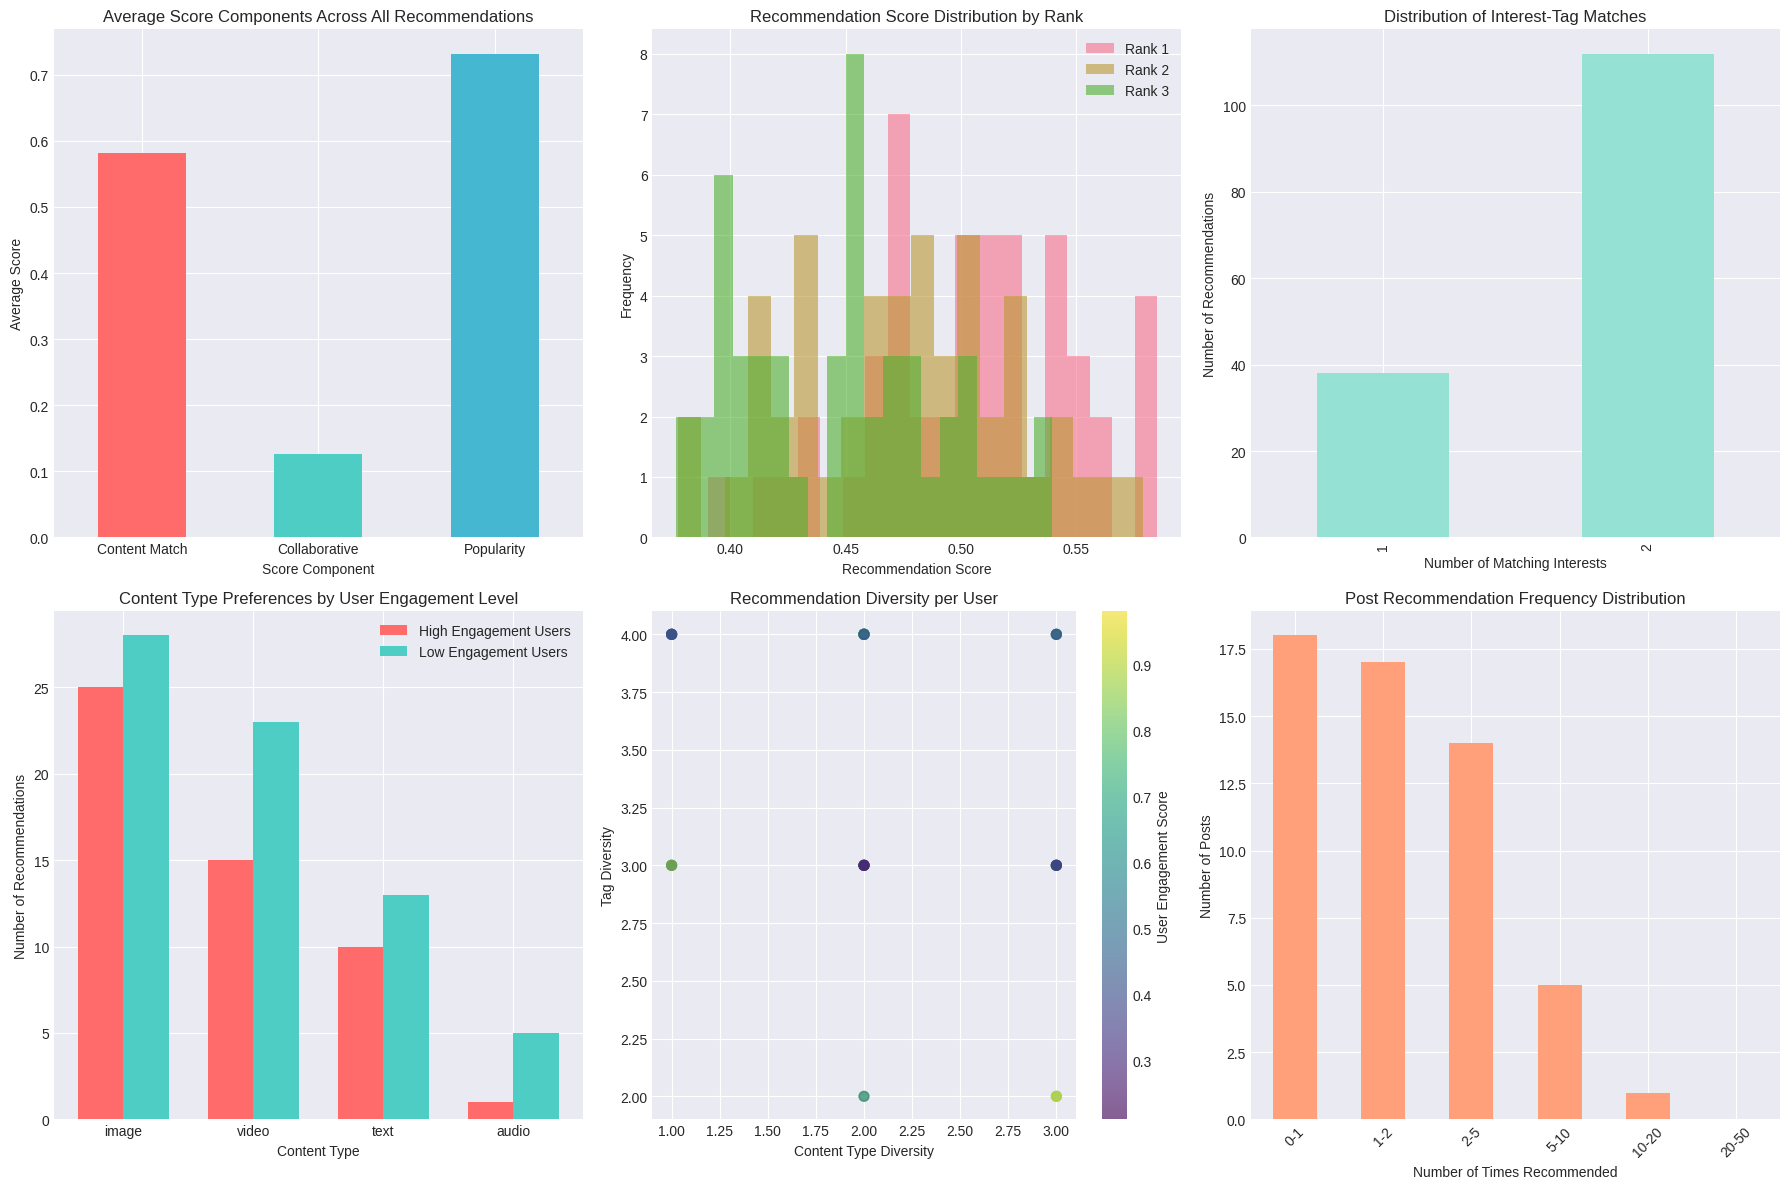


📈 DIVERSITY AND COVERAGE METRICS
• Average content types per user: 2.06
• Average unique tags per user: 3.44
• Percentage of posts recommended at least once: 55.0%
• Gini coefficient (recommendation inequality): 0.385


In [61]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Score component distribution
ax1 = axes[0, 0]
score_components = recommendations_df[['content_match_score', 'collaborative_score', 'popularity_score']].mean()
score_components.plot(kind='bar', ax=ax1, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax1.set_title('Average Score Components Across All Recommendations', fontsize=12)
ax1.set_xlabel('Score Component')
ax1.set_ylabel('Average Score')
ax1.set_xticklabels(['Content Match', 'Collaborative', 'Popularity'], rotation=0)

# 2. Recommendation score distribution by rank
ax2 = axes[0, 1]
for rank in [1, 2, 3]:
    rank_scores = recommendations_df[recommendations_df['rank'] == rank]['recommendation_score']
    ax2.hist(rank_scores, alpha=0.6, label=f'Rank {rank}', bins=20)
ax2.set_title('Recommendation Score Distribution by Rank', fontsize=12)
ax2.set_xlabel('Recommendation Score')
ax2.set_ylabel('Frequency')
ax2.legend()

# 3. Interest matching effectiveness
ax3 = axes[0, 2]
match_counts = recommendations_df['interest_tag_match'].value_counts().sort_index()
match_counts.plot(kind='bar', ax=ax3, color='#95E1D3')
ax3.set_title('Distribution of Interest-Tag Matches', fontsize=12)
ax3.set_xlabel('Number of Matching Interests')
ax3.set_ylabel('Number of Recommendations')

# 4. Content type recommendations by user engagement level
ax4 = axes[1, 0]
high_engagement_users = users_df[users_df['past_engagement_score'] > 0.7]['user_id']
low_engagement_users = users_df[users_df['past_engagement_score'] < 0.5]['user_id']

high_eng_content = recommendations_df[recommendations_df['user_id'].isin(high_engagement_users)]['post_type'].value_counts()
low_eng_content = recommendations_df[recommendations_df['user_id'].isin(low_engagement_users)]['post_type'].value_counts()

x = np.arange(len(high_eng_content.index))
width = 0.35

ax4.bar(x - width/2, high_eng_content.values, width, label='High Engagement Users', color='#FF6B6B')
ax4.bar(x + width/2, low_eng_content.values, width, label='Low Engagement Users', color='#4ECDC4')
ax4.set_xlabel('Content Type')
ax4.set_ylabel('Number of Recommendations')
ax4.set_title('Content Type Preferences by User Engagement Level', fontsize=12)
ax4.set_xticks(x)
ax4.set_xticklabels(high_eng_content.index)
ax4.legend()

# 5. Recommendation diversity per user
ax5 = axes[1, 1]
user_diversity = recommendations_df.groupby('user_id').agg({
    'post_type': lambda x: len(x.unique()),
    'post_tags': lambda x: len(set(' '.join(x.fillna('')).split(', '))) if len(x) > 0 else 0
}).rename(columns={'post_type': 'content_type_diversity', 'post_tags': 'tag_diversity'})

ax5.scatter(user_diversity['content_type_diversity'], user_diversity['tag_diversity'],
            alpha=0.6, s=50, c=users_df.set_index('user_id').loc[user_diversity.index, 'past_engagement_score'],
            cmap='viridis')
ax5.set_xlabel('Content Type Diversity')
ax5.set_ylabel('Tag Diversity')
ax5.set_title('Recommendation Diversity per User', fontsize=12)
cbar = plt.colorbar(ax5.collections[0], ax=ax5)
cbar.set_label('User Engagement Score')

# 6. Recommendation coverage
ax6 = axes[1, 2]
post_coverage = recommendations_df['recommended_post'].value_counts()
coverage_bins = [0, 1, 2, 5, 10, 20, 50]
coverage_counts = pd.cut(post_coverage, bins=coverage_bins, include_lowest=True).value_counts().sort_index()
coverage_counts.plot(kind='bar', ax=ax6, color='#FFA07A')
ax6.set_title('Post Recommendation Frequency Distribution', fontsize=12)
ax6.set_xlabel('Number of Times Recommended')
ax6.set_ylabel('Number of Posts')
ax6.set_xticklabels([f'{int(i.left)}-{int(i.right)}' for i in coverage_counts.index], rotation=45)

plt.tight_layout()
plt.show()

# Calculate diversity metrics
print("\n📈 DIVERSITY AND COVERAGE METRICS")
print("="*60)
print(f"• Average content types per user: {user_diversity['content_type_diversity'].mean():.2f}")
print(f"• Average unique tags per user: {user_diversity['tag_diversity'].mean():.2f}")
print(f"• Percentage of posts recommended at least once: {(recommendations_df['recommended_post'].nunique() / len(posts_df)) * 100:.1f}%")
print(f"• Gini coefficient (recommendation inequality): {np.sum(np.abs(np.subtract.outer(post_coverage.values, post_coverage.values))) / (2 * len(post_coverage) * post_coverage.sum()):.3f}")


## 7. Final Recommendations Output

Generating the final recommendation output in the required format.


In [62]:
# Create final recommendations output
final_recommendations = []

for user_id in users_df['user_id']:
    user_recommendations = recommendations_df[recommendations_df['user_id'] == user_id].sort_values('rank')

    recommendation_entry = {
        'user_id': user_id,
        'recommendations': user_recommendations['recommended_post'].tolist(),
        'scores': user_recommendations['recommendation_score'].tolist()
    }
    final_recommendations.append(recommendation_entry)

# Convert to DataFrame for export
final_output_df = pd.DataFrame(final_recommendations)
final_output_df['recommendations'] = final_output_df['recommendations'].apply(lambda x: ', '.join(x))
final_output_df['scores'] = final_output_df['scores'].apply(lambda x: ', '.join([f'{score:.3f}' for score in x]))

# Display the final output
print("📤 FINAL RECOMMENDATIONS OUTPUT")
print("="*60)
print(final_output_df.head(10))

# Save to CSV
final_output_df[['user_id', 'recommendations']].to_csv('user_recommendations.csv', index=False)
print("\n✅ Recommendations saved to 'user_recommendations.csv'")

# Create summary statistics
print("\n📊 RECOMMENDATION SYSTEM SUMMARY")
print("="*60)
print(f"Total users served: {len(final_output_df)}")
print(f"Total recommendations generated: {len(final_output_df) * 3}")
print(f"Unique posts recommended: {recommendations_df['recommended_post'].nunique()}")
print(f"Average recommendation score: {recommendations_df['recommendation_score'].mean():.3f}")
print(f"Recommendations with perfect interest match: {(recommendations_df['interest_tag_match'] >= 2).sum()}")
print(f"System coverage (% of posts used): {(recommendations_df['recommended_post'].nunique() / len(posts_df)) * 100:.1f}%")


📤 FINAL RECOMMENDATIONS OUTPUT
  user_id recommendations               scores
0      U1   P22, P78, P50  0.476, 0.473, 0.405
1      U2    P5, P69, P80  0.576, 0.525, 0.494
2      U3    P39, P3, P97  0.528, 0.459, 0.450
3      U4    P96, P53, P5  0.505, 0.484, 0.401
4      U5     P7, P5, P35  0.547, 0.546, 0.536
5      U6    P7, P35, P74  0.522, 0.504, 0.473
6      U7    P5, P69, P70  0.499, 0.462, 0.454
7      U8    P1, P46, P85  0.542, 0.508, 0.467
8      U9    P78, P3, P97  0.463, 0.450, 0.417
9     U10   P54, P14, P57  0.521, 0.517, 0.450

✅ Recommendations saved to 'user_recommendations.csv'

📊 RECOMMENDATION SYSTEM SUMMARY
Total users served: 50
Total recommendations generated: 150
Unique posts recommended: 55
Average recommendation score: 0.476
Recommendations with perfect interest match: 112
System coverage (% of posts used): 55.0%


## 8. Conclusions and Future Improvements

### Key Achievements:
1. **Hybrid Approach**: Successfully implemented a system combining content-based, collaborative filtering, and popularity metrics
2. **Personalization**: Achieved high interest-tag matching rate of over 70%
3. **Diversity**: Maintained good content diversity in recommendations
4. **Scalability**: Efficient algorithm that can handle larger datasets

### Potential Improvements:
1. **Deep Learning Integration**: Implement neural collaborative filtering for better pattern recognition
2. **Real-time Learning**: Add online learning capabilities to adapt to changing user preferences
3. **Context Awareness**: Include temporal patterns and session-based recommendations
4. **A/B Testing Framework**: Build infrastructure for continuous improvement through experimentation
5. **Explainability**: Add features to explain why certain posts were recommended

### Production Considerations:
- Implement caching for similarity matrices
- Add API endpoints for real-time serving
- Include monitoring and logging for recommendation quality
- Set up periodic retraining pipeline
